# Joint Thesis Results Synthesis — Standalone       

Most cells in Parts I and II are structurally identical to the corresponding cells in the individual notebooks      

Notebook structure:     
- Sections 1–3: Imports, data loading, audit, feature set definitions       
- Sections 4–10 (PART I): variable distributions, failure-rate patterns, relationship plots, subtype interpretation, operator-support framing       
- Sections 11–19 (PART II): train/test split, model comparison, imbalance handling, tuning, final evaluation, threshold analysis, interpretability, synthetic-rule sensitivity audit, subtype recall, robustness test       
- Sections 20–24 (PART III): Joint synthesis        

## 1. Imports, reproducibility, and environment     

In [83]:
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, classification_report, ConfusionMatrixDisplay,
    f1_score, fbeta_score, make_scorer, precision_score, recall_score, roc_auc_score,
    PrecisionRecallDisplay, RocCurveDisplay, precision_recall_curve, roc_curve,
)
from sklearn.model_selection import (
    cross_validate, GridSearchCV, StratifiedKFold, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier

# Required modelling extras
import xgboost
from xgboost import XGBClassifier
import imblearn
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Environment summary
print("Python      :", platform.python_version())
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("matplotlib  :", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost     :", xgboost.__version__)
print("imbalanced  :", imblearn.__version__)
print("shap        :", shap.__version__)

Python      : 3.11.14
numpy       : 2.4.4
pandas      : 3.0.2
matplotlib  : 3.10.8
scikit-learn: 1.8.0
xgboost     : 3.2.0
imbalanced  : 0.14.1
shap        : 0.51.0


In [84]:
# OneHotEncoder
def make_ohe(drop="first"):
    try:
        return OneHotEncoder(drop=drop, sparse_output=False, handle_unknown="ignore")
    except TypeError:
        return OneHotEncoder(drop=drop, sparse=False, handle_unknown="ignore")

# Smoke test
_test = make_ohe()
print("Constructed:", type(_test).__name__)

Constructed: OneHotEncoder


## 2. Data loading and audit        

In [85]:
df_raw = pd.read_csv("ai4i2020.csv")
df_raw.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [86]:
quality = pd.DataFrame({
    "dtype":          df_raw.dtypes.astype(str),
    "missing_values": df_raw.isna().sum(),
    "missing_%":      (df_raw.isna().mean() * 100).round(2),
    "n_unique":       df_raw.nunique(),
})
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
quality

Duplicate rows: 0


,dtype,missing_values,missing_%,n_unique
UDI,int64,0,0.0,10000
Product ID,str,0,0.0,10000
Type,str,0,0.0,3
Air temperature [K],float64,0,0.0,93
Process temperature [K],float64,0,0.0,82
Rotational speed [rpm],int64,0,0.0,941
Torque [Nm],float64,0,0.0,577
Tool wear [min],int64,0,0.0,246
Machine failure,int64,0,0.0,2
TWF,int64,0,0.0,2


### 2.1 Column roles and leakage policy     

In [87]:
TARGET = "Machine failure"
ID_COLS = ["UDI", "Product ID"]
SUBTYPE_COLS = ["TWF", "HDF", "PWF", "OSF", "RNF"]

BASE_FEATURES = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

NUMERIC_BASE = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

# Leakage guard
forbidden = set(SUBTYPE_COLS + ID_COLS + [TARGET])
for f in BASE_FEATURES:
    assert f not in forbidden, f"Leakage: {f} appears in BASE_FEATURES"
print("Leakage guard passed: no subtype/id/target columns are in BASE_FEATURES.")

Leakage guard passed: no subtype/id/target columns are in BASE_FEATURES.


In [88]:
# Class distribution
tc = df_raw[TARGET].value_counts().rename_axis("class").reset_index(name="count")
tc["percent"] = (tc["count"] / len(df_raw) * 100).round(3)
print(tc.to_string(index=False))
ratio = tc.loc[tc["class"]==0, "count"].values[0] / tc.loc[tc["class"]==1, "count"].values[0]
print(f"\nImbalance ratio (majority : minority) ≈ {ratio:.1f} : 1")

 class  count  percent
     0   9661    96.61
     1    339     3.39

Imbalance ratio (majority : minority) ≈ 28.5 : 1


The subtype counts table below uses `df_raw` because `df` (with audit columns) is built in Section 3        

In [89]:
# Subtype support counts and OR-consistency check
sub_counts = df_raw[SUBTYPE_COLS].sum().rename("count").to_frame()
sub_counts["share_of_failures_%"] = (sub_counts["count"] / df_raw[TARGET].sum() * 100).round(2)
print("Subtype support counts (sum across rows):")
print(sub_counts)

subtype_or = df_raw[SUBTYPE_COLS].any(axis=1).astype(int)
matches = (subtype_or == df_raw[TARGET])
n_mismatch = int((~matches).sum())
print(f"\nDoes Machine failure equal OR(TWF,HDF,PWF,OSF,RNF)?  matches: {int(matches.sum())} / {len(df_raw)}")
print(f"Mismatches: {n_mismatch}")
if n_mismatch > 0:
    mismatch_table = (df_raw.loc[~matches, [TARGET] + SUBTYPE_COLS]
                          .assign(subtype_OR=subtype_or[~matches])
                          .head(10))
    print("\nFirst 10 mismatching rows:")
    print(mismatch_table.to_string())

Subtype support counts (sum across rows):
     count  share_of_failures_%
TWF     46                13.57
HDF    115                33.92
PWF     95                28.02
OSF     98                28.91
RNF     19                 5.60

Does Machine failure equal OR(TWF,HDF,PWF,OSF,RNF)?  matches: 9973 / 10000
Mismatches: 27

First 10 mismatching rows:
      Machine failure  TWF  HDF  PWF  OSF  RNF  subtype_OR
1221                0    0    0    0    0    1           1
1302                0    0    0    0    0    1           1
1437                1    0    0    0    0    0           0
1748                0    0    0    0    0    1           1
2072                0    0    0    0    0    1           1
2559                0    0    0    0    0    1           1
2749                1    0    0    0    0    0           0
3065                0    0    0    0    0    1           1
3452                0    0    0    0    0    1           1
4044                1    0    0    0    0    0           

## 3. Feature set definitions       

Three feature sets are defined in this notebook:        

| Set | Contents |
|---|---|
| **raw_features** | Six base sensor variables (`Type`, air/process temperature, rotational speed, torque, tool wear) |
| **engineered_features** | raw + `Power` (Torque × ω), `Overstrain` (Torque × Tool wear), `Heat_dissipation` (rpm × ΔT) — the three raw-product features from Patel and Shanbhag (2022) |
| **rule_audit_features** | raw + three threshold-distance features derived from Matzka's (2020) HDF / PWF / OSF generation thresholds |

Neither `engineered_features` nor `rule_audit_features` are used in the reported model. They are reserved solely for the Section 11 sensitivity audit       

In [90]:
df = df_raw.copy()

# Rule-audit features — DIAGNOSTIC ONLY (used in Section 17 sensitivity audit only).
# Intermediate computations kept as local variables, not added as named df columns.
_power      = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * (2 * np.pi / 60)
_temp_diff  = df["Process temperature [K]"] - df["Air temperature [K]"]
_overstrain = df["Torque [Nm]"] * df["Tool wear [min]"]
_osf_thresh = df["Type"].map({"L": 11000, "M": 12000, "H": 13000})

df["Power_band_violation"] = (
    np.maximum(0, 3500 - _power) + np.maximum(0, _power - 9000)
)
df["HDF_combined_risk"] = (
    np.maximum(0, 8.6 - _temp_diff)
    * np.maximum(0, 1380 - df["Rotational speed [rpm]"])
)
df["OSF_violation"] = np.maximum(0, _overstrain - _osf_thresh)

# P&S-style engineered features — DIAGNOSTIC ONLY (Section 11/17 audit).
df["Power"]            = _power
df["Overstrain"]       = _overstrain
df["Heat_dissipation"] = df["Rotational speed [rpm]"] * _temp_diff

raw_features        = BASE_FEATURES.copy()
rule_audit_features = BASE_FEATURES + [
    "Power_band_violation", "HDF_combined_risk", "OSF_violation",
]
engineered_features = BASE_FEATURES + [
    "Power", "Overstrain", "Heat_dissipation",
]

print(f"NUMERIC_BASE        : {len(NUMERIC_BASE):2d} numeric columns (for EDA)")
print(f"raw_features        : {len(raw_features):2d} columns")
print(f"engineered_features : {len(engineered_features):2d} columns")
print(f"rule_audit_features : {len(rule_audit_features):2d} columns")

NUMERIC_BASE        :  5 numeric columns (for EDA)
raw_features        :  6 columns
engineered_features :  9 columns
rule_audit_features :  9 columns


## 4. Exploratory failure overview      

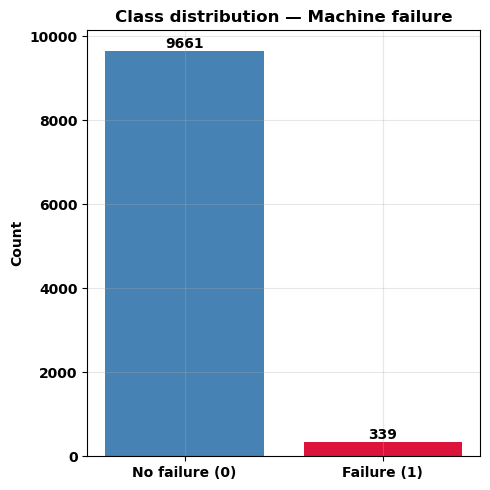

In [91]:
# Class imbalance
fig, ax = plt.subplots(figsize=(5, 5))
counts = tc.sort_values("class")["count"].values
bars = ax.bar(["No failure (0)", "Failure (1)"], counts, color=["steelblue", "crimson"])
ax.bar_label(bars, fmt="%d")
ax.set_title("Class distribution — Machine failure")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

      failures  total  failure_rate_%
Type                                 
H           21   1003            2.09
L          235   6000            3.92
M           83   2997            2.77


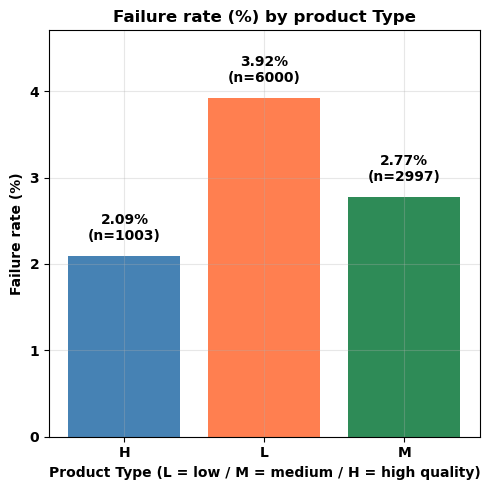

In [92]:
# Failure rate by Type
fbt = (df.groupby("Type")[TARGET]
       .agg(["sum", "count"])
       .rename(columns={"sum": "failures", "count": "total"}))
fbt["failure_rate_%"] = (fbt["failures"] / fbt["total"] * 100).round(2)
print(fbt)

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(fbt.index, fbt["failure_rate_%"], color=["steelblue", "coral", "seagreen"])
ax.set_title("Failure rate (%) by product Type")
ax.set_ylabel("Failure rate (%)")
ax.set_xlabel("Product Type (L = low / M = medium / H = high quality)")
ax.set_ylim(0, fbt["failure_rate_%"].max() * 1.2)
for i, (typ, row) in enumerate(fbt.iterrows()):
    ax.text(i, row["failure_rate_%"] + 0.15, f"{row['failure_rate_%']}%\n(n={int(row['total'])})",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

## 5. Variable distributions by failure status      

In [93]:
# Summary table — mean, median, std for failures vs non-failures
def summary_by_failure(df, cols):
    rows = []
    for c in cols:
        for cls in [0, 1]:
            sub = df.loc[df[TARGET] == cls, c]
            rows.append({
                "variable": c,
                "class": "Failure" if cls == 1 else "No failure",
                "n": len(sub),
                "mean": sub.mean(),
                "median": sub.median(),
                "std": sub.std(),
                "min": sub.min(),
                "max": sub.max(),
            })
    return pd.DataFrame(rows)

summary_df = summary_by_failure(df, NUMERIC_BASE)
print(summary_df.round(3).to_string(index=False))

               variable      class    n     mean  median     std    min    max
    Air temperature [K] No failure 9661  299.974   300.0   1.991  295.3  304.5
    Air temperature [K]    Failure  339  300.886   301.6   2.071  295.6  304.4
Process temperature [K] No failure 9661  309.996   310.0   1.487  305.7  313.8
Process temperature [K]    Failure  339  310.290   310.4   1.364  306.1  313.7
 Rotational speed [rpm] No failure 9661 1540.260  1507.0 167.395 1168.0 2695.0
 Rotational speed [rpm]    Failure  339 1496.487  1365.0 384.944 1181.0 2886.0
            Torque [Nm] No failure 9661   39.630    39.9   9.472   12.6   70.0
            Torque [Nm]    Failure  339   50.168    53.7  16.374    3.8   76.6
        Tool wear [min] No failure 9661  106.694   107.0  62.946    0.0  246.0
        Tool wear [min]    Failure  339  143.782   165.0  72.760    0.0  253.0


               variable  Cohen's d (failure − no failure)
            Torque [Nm]                             1.077
        Tool wear [min]                             0.586
    Air temperature [K]                             0.458
 Rotational speed [rpm]                            -0.244
Process temperature [K]                             0.199


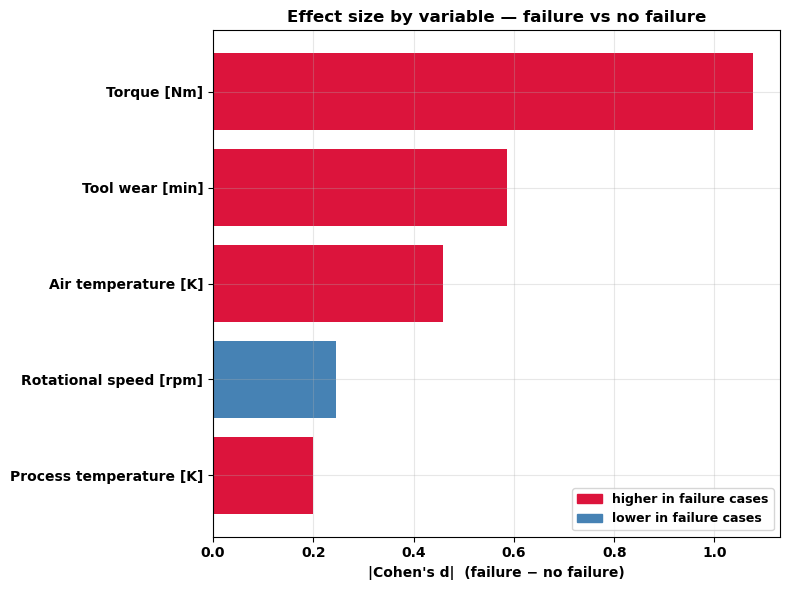

In [94]:
# Standardised mean difference (Cohen's d)
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx, sy = x.std(), y.std()
    pooled = np.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled if pooled > 0 else np.nan

eff = []
for c in NUMERIC_BASE:
    xf = df.loc[df[TARGET] == 1, c]
    xn = df.loc[df[TARGET] == 0, c]
    eff.append({"variable": c, "Cohen's d (failure − no failure)": cohens_d(xf, xn)})
eff_df = pd.DataFrame(eff).sort_values("Cohen's d (failure − no failure)",
                                      key=abs, ascending=False).reset_index(drop=True)
print(eff_df.round(3).to_string(index=False))

# Cohen's d bar chart
d_col = "Cohen's d (failure − no failure)"
plot_df = eff_df.copy()
plot_df["abs_d"] = plot_df[d_col].abs()
plot_df = plot_df.sort_values("abs_d", ascending=True)  # ascending for barh

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["crimson" if v > 0 else "steelblue" for v in plot_df[d_col]]
ax.barh(plot_df["variable"], plot_df["abs_d"], color=colors)

# Add a legend for direction
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="crimson",   label="higher in failure cases"),
    Patch(color="steelblue", label="lower in failure cases"),
], fontsize=9)

ax.set_xlabel("|Cohen's d|  (failure − no failure)")
ax.set_title("Effect size by variable — failure vs no failure")
plt.tight_layout()
plt.show()

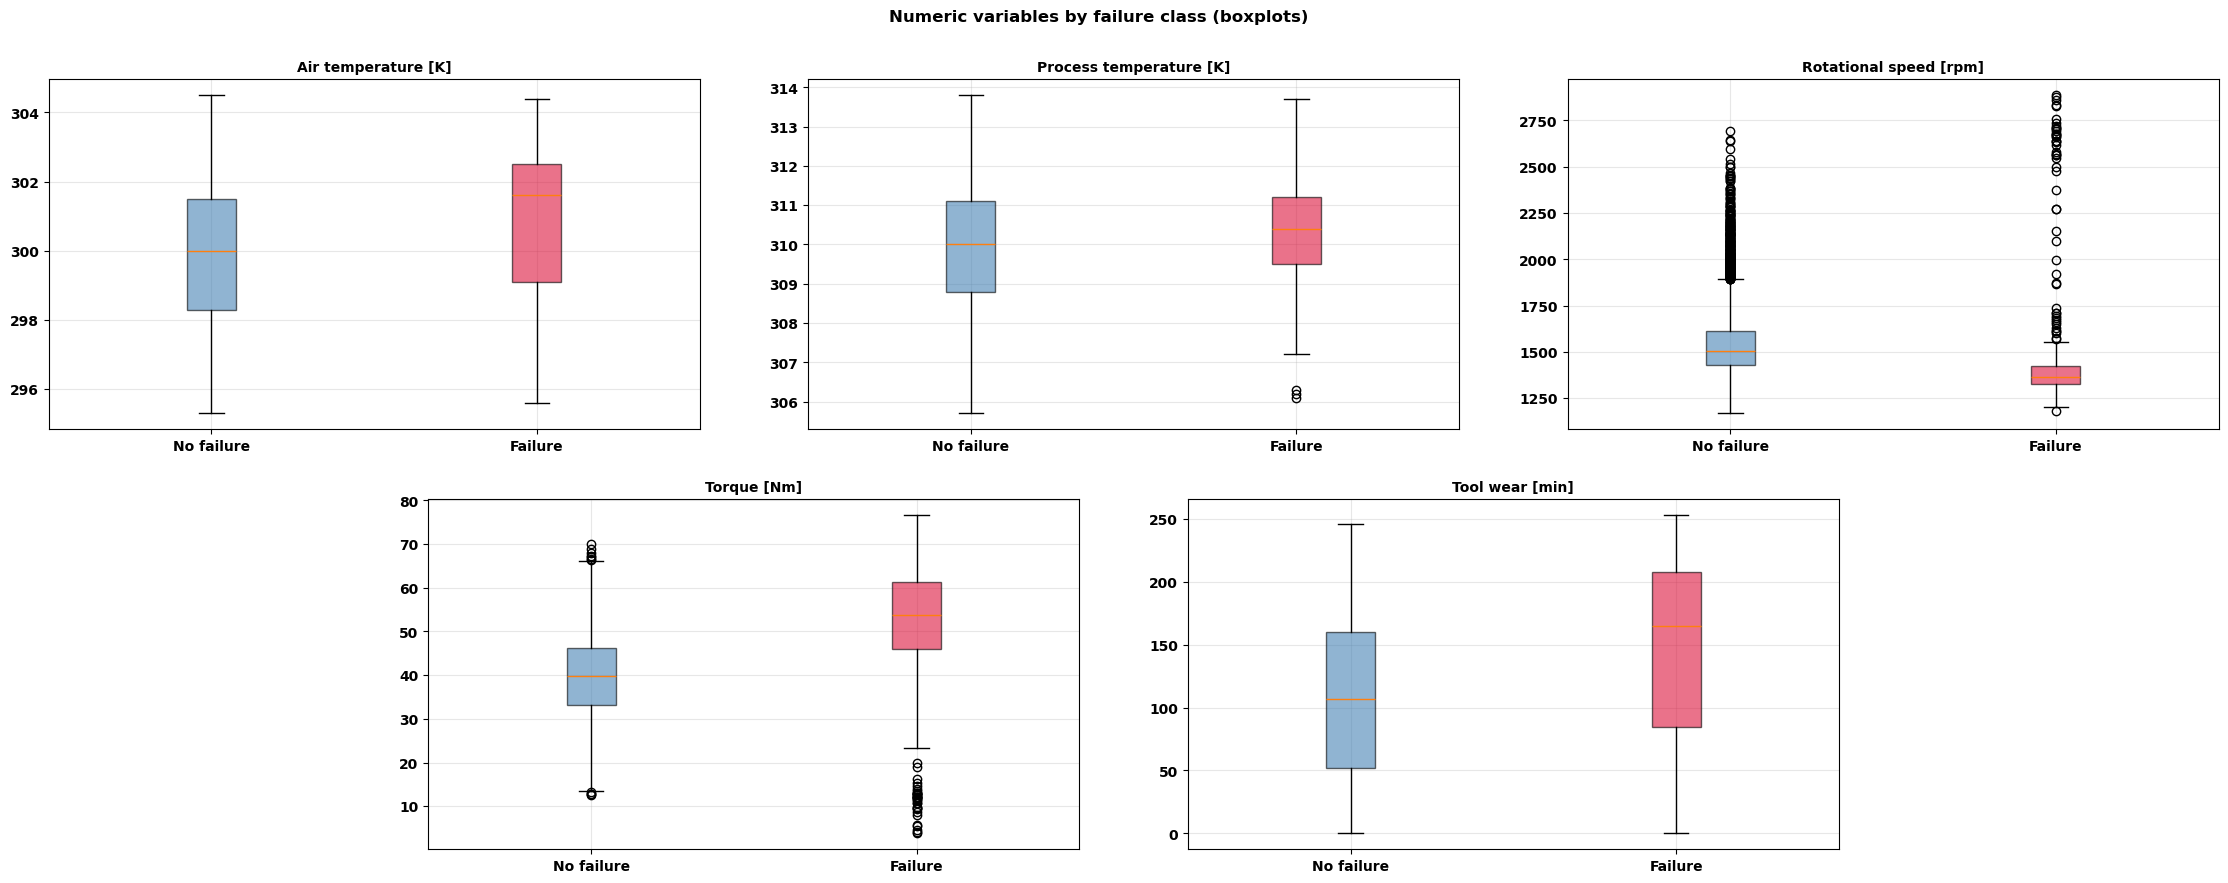

In [95]:
# Boxplots by failure class
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(28, 10))
gs  = gridspec.GridSpec(2, 6, figure=fig, hspace=0.2, wspace=0.40)
ax_top = [fig.add_subplot(gs[0, i*2:(i+1)*2]) for i in range(3)]
ax_bot = [fig.add_subplot(gs[1, 1:3]), fig.add_subplot(gs[1, 3:5])]
axes = ax_top + ax_bot

for ax, col in zip(axes, NUMERIC_BASE):
    data_pairs = [df.loc[df[TARGET] == 0, col], df.loc[df[TARGET] == 1, col]]
    bp = ax.boxplot(data_pairs, tick_labels=["No failure", "Failure"], patch_artist=True)
    for patch, color in zip(bp["boxes"], ["steelblue", "crimson"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(col, fontsize=10)

plt.suptitle("Numeric variables by failure class (boxplots)", y=0.95)
plt.show()

## 6. Failure-rate pattern analysis     

For each main variable, the data is divided into quantile bins and the failure rate per bin is computed     
Bin-level support counts are reported alongside the rate so small bins are not over-interpreted     

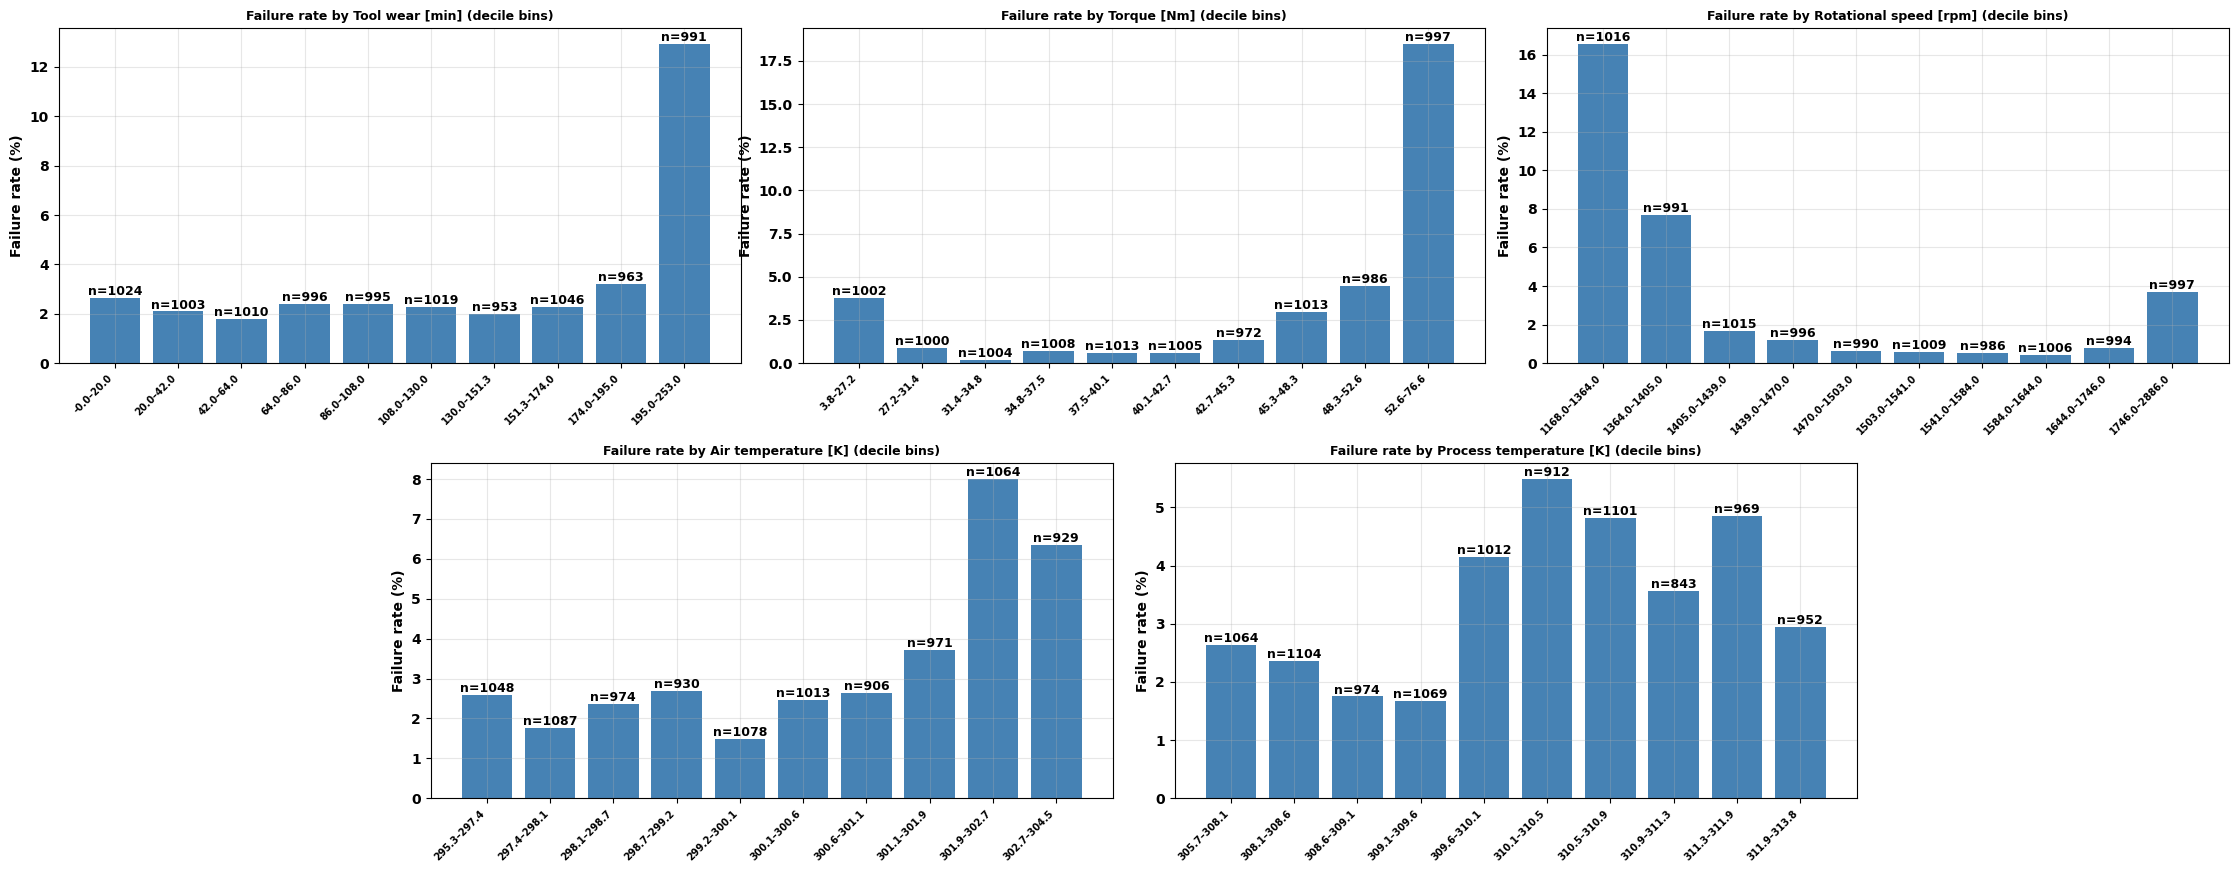

In [96]:
def failure_rate_by_quantile(df, col, q=10):
    bins = pd.qcut(df[col], q=q, duplicates="drop")
    g = df.groupby(bins, observed=True)[TARGET].agg(["sum", "count"])
    g["failure_rate_%"] = (g["sum"] / g["count"] * 100).round(2)
    g.index.name = f"{col} (quantile bin)"
    return g

binned_targets = ["Tool wear [min]", "Torque [Nm]", "Rotational speed [rpm]",
                  "Air temperature [K]", "Process temperature [K]"]

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(28, 10))
gs  = gridspec.GridSpec(2, 6, figure=fig, hspace=0.3, wspace=0.2)
ax_top = [fig.add_subplot(gs[0, i*2:(i+1)*2]) for i in range(3)]
ax_bot = [fig.add_subplot(gs[1, 1:3]), fig.add_subplot(gs[1, 3:5])]
axes = ax_top + ax_bot

all_binned = {}
for ax, col in zip(axes, binned_targets):
    g = failure_rate_by_quantile(df, col, q=10)
    all_binned[col] = g
    x = np.arange(len(g))
    ax.bar(x, g["failure_rate_%"], color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i.left:.1f}–{i.right:.1f}" for i in g.index],
                       rotation=45, ha="right", fontsize=7)
    for i, n in enumerate(g["count"].values):
        ax.text(i, g["failure_rate_%"].iloc[i], f"n={n}",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Failure rate by {col} (decile bins)", fontsize=9)
    ax.set_ylabel("Failure rate (%)")

plt.show()

## 7. Relationship plots        

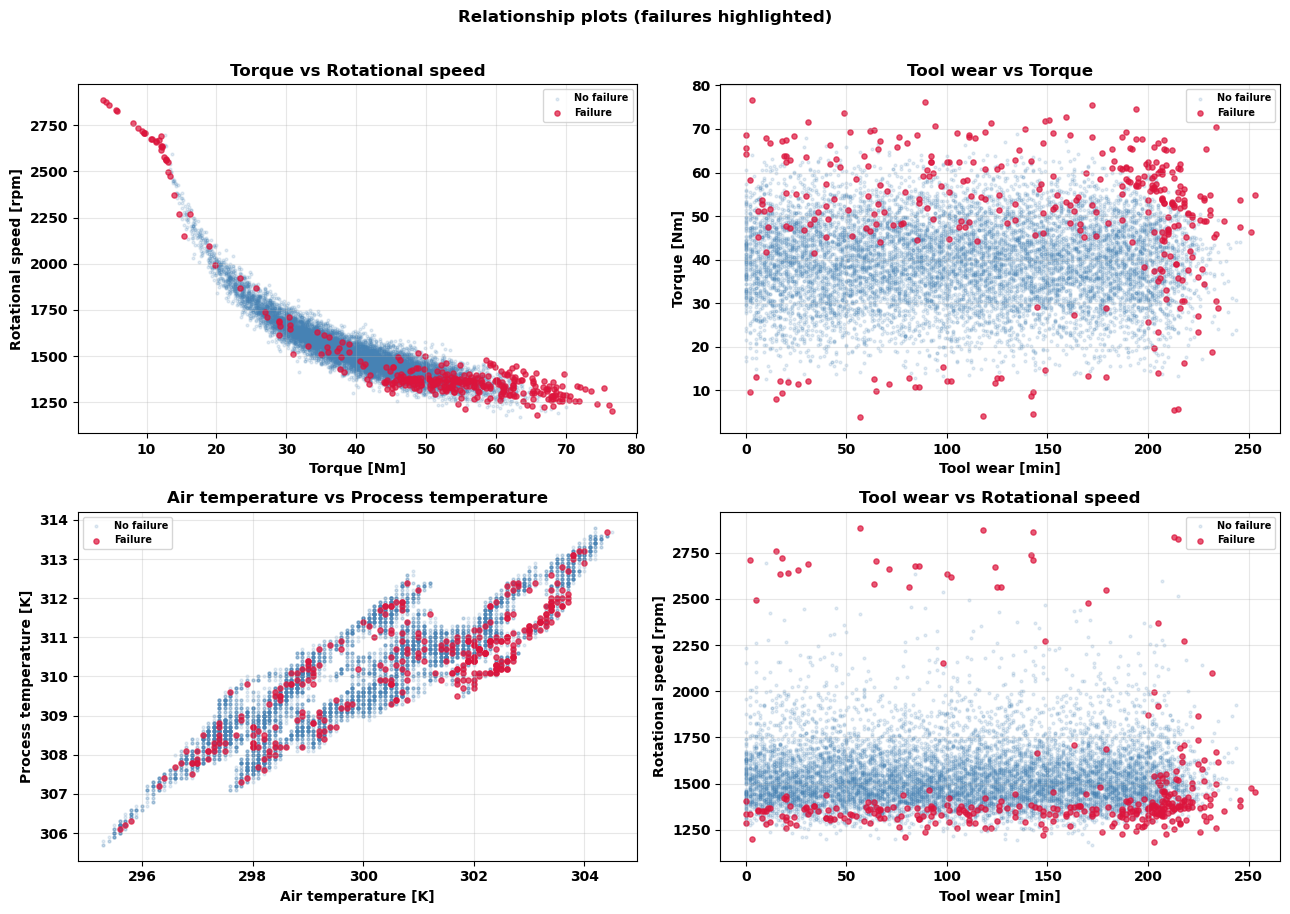

In [97]:
# Helper to plot a 2D scatter coloured by failure status
def scatter_by_failure(df, x, y, ax):
    nf = df[df[TARGET] == 0]
    f  = df[df[TARGET] == 1]
    ax.scatter(nf[x], nf[y], s=4, alpha=0.15, color="steelblue", label="No failure")
    ax.scatter(f[x],  f[y],  s=14, alpha=0.7, color="crimson", label="Failure")
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
scatter_by_failure(df, "Torque [Nm]", "Rotational speed [rpm]", axes[0, 0])
axes[0, 0].set_title("Torque vs Rotational speed")
scatter_by_failure(df, "Tool wear [min]", "Torque [Nm]", axes[0, 1])
axes[0, 1].set_title("Tool wear vs Torque")
scatter_by_failure(df, "Air temperature [K]", "Process temperature [K]", axes[1, 0])
axes[1, 0].set_title("Air temperature vs Process temperature")
scatter_by_failure(df, "Tool wear [min]", "Rotational speed [rpm]", axes[1, 1])
axes[1, 1].set_title("Tool wear vs Rotational speed")
plt.suptitle("Relationship plots (failures highlighted)", y=1.01)
plt.tight_layout()
plt.show()

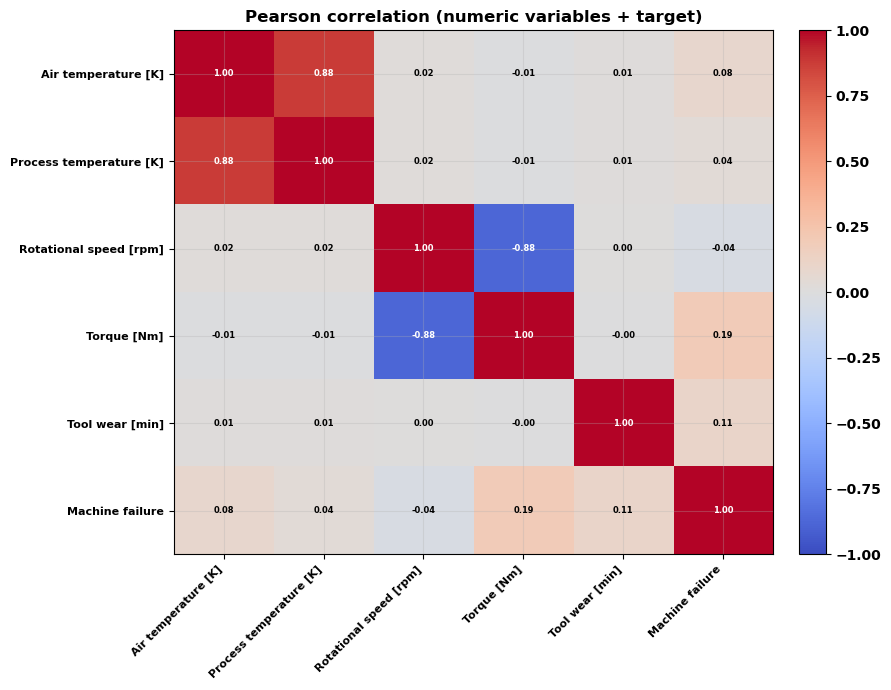

In [98]:
# Correlation heatmap (with target)
corr_cols = NUMERIC_BASE + [TARGET]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(v) > 0.6 else "black")
ax.set_title("Pearson correlation (numeric variables + target)")
plt.tight_layout()
plt.show()

## 8. Subtype-specific interpretation       

For each failure subtype, summary statistics of the main variables are computed and compared to the no-failure group        

In [99]:
subtype_long_rows = []
for sub in SUBTYPE_COLS:
    n = int(df[sub].sum())
    if n == 0:
        continue
    sub_data = df[df[sub] == 1]
    no_data  = df[df[TARGET] == 0]
    for col in NUMERIC_BASE:
        d = cohens_d(sub_data[col], no_data[col])
        subtype_long_rows.append({
            "Subtype": sub, "n": n,
            "variable": col,
            "subtype_mean": sub_data[col].mean(),
            "no_failure_mean": no_data[col].mean(),
            "Cohen's d (subtype − no failure)": d,
        })

subtype_eff = pd.DataFrame(subtype_long_rows)
print("Subtype effect-size summary (sorted by |d|, top 15):")
print(subtype_eff.assign(abs_d=lambda x: x["Cohen's d (subtype − no failure)"].abs())
                   .sort_values("abs_d", ascending=False)
                   .drop(columns=["abs_d"])
                   .head(15)
                   .round(3)
                   .to_string(index=False))

Subtype effect-size summary (sorted by |d|, top 15):
Subtype   n                variable  subtype_mean  no_failure_mean  Cohen's d (subtype − no failure)
    OSF  98             Torque [Nm]        58.370           39.630                             1.985
    TWF  46         Tool wear [min]       216.370          106.694                             1.746
    OSF  98         Tool wear [min]       207.694          106.694                             1.612
    HDF 115             Torque [Nm]        53.167           39.630                             1.434
    HDF 115     Air temperature [K]       302.561          299.974                             1.306
    PWF  95  Rotational speed [rpm]      1763.968         1540.260                             1.261
    HDF 115  Rotational speed [rpm]      1337.261         1540.260                            -1.220
    OSF  98  Rotational speed [rpm]      1350.327         1540.260                            -1.140
    PWF  95             Torque [Nm]   

In [100]:
# Top-associated variable per subtype
top_var_per_sub = (subtype_eff.assign(abs_d=lambda x: x["Cohen's d (subtype − no failure)"].abs())
                              .sort_values(["Subtype", "abs_d"], ascending=[True, False])
                              .groupby("Subtype")
                              .head(1))
print("Top-associated variable per subtype:")
print(top_var_per_sub.round(3).to_string(index=False))

Top-associated variable per subtype:
Subtype   n                variable  subtype_mean  no_failure_mean  Cohen's d (subtype − no failure)  abs_d
    HDF 115             Torque [Nm]        53.167           39.630                             1.434  1.434
    OSF  98             Torque [Nm]        58.370           39.630                             1.985  1.985
    PWF  95  Rotational speed [rpm]      1763.968         1540.260                             1.261  1.261
    RNF  19 Process temperature [K]       310.763          309.996                             0.516  0.516
    TWF  46         Tool wear [min]       216.370          106.694                             1.746  1.746


## 9. Non-optimal operating condition patterns

In [101]:
# Define candidate "high-risk" regions and report failure rate / support
def region_summary(df, mask, label):
    n = int(mask.sum())
    if n == 0:
        return {"region": label, "n": 0, "failures": 0, "failure_rate_%": np.nan}
    fails = int((df.loc[mask, TARGET] == 1).sum())
    return {"region": label, "n": n, "failures": fails,
            "failure_rate_%": round(100 * fails / n, 2)}

regions = [
    region_summary(df, df["Tool wear [min]"] > 200,
                   "Tool wear > 200 min"),
    region_summary(df, (df["Tool wear [min]"] > 200) & (df["Torque [Nm]"] > 50),
                   "Tool wear > 200 AND Torque > 50 Nm"),
    region_summary(df, df["Rotational speed [rpm]"] < 1380,
                   "Rotational speed < 1380 rpm"),
    region_summary(df, df["Torque [Nm]"] > 60,
                   "Torque > 60 Nm"),
    region_summary(df,
                   (df["Process temperature [K]"] - df["Air temperature [K]"]) < 8.6,
                   "Process temp - Air temp < 8.6 K"),
]
regions_df = pd.DataFrame(regions)
print(regions_df.to_string(index=False))

                            region    n  failures  failure_rate_%
               Tool wear > 200 min  762       118           15.49
Tool wear > 200 AND Torque > 50 Nm  107        62           57.94
       Rotational speed < 1380 rpm 1360       218           16.03
                    Torque > 60 Nm  236        99           41.95
   Process temp - Air temp < 8.6 K  720       126           17.50


Part II begins below:       
The modelling-support EDA from Mazen's notebook (class imbalance bar, numeric summaries by class, density-normalised distributions, correlation heatmap) is not repeated here since Robin's full EDA in Part I already covers those plots too       

## 11. Train/test split and preprocessing       

Single stratified split, `test_size = 0.20`     
The test set is held out and used only for the final evaluation     
All cross-validation, model selection, hyperparameter tuning, and resampling is performed inside the training set, with resamplers placed inside CV pipelines so they only see training folds       

In [102]:
y = df[TARGET]
X_full = df.drop(columns=[TARGET] + SUBTYPE_COLS + ID_COLS)

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {X_train_full.shape[0]:,} rows | failures: {y_train.sum():3d} ({y_train.mean()*100:.2f}%)")
print(f"Test : {X_test_full.shape[0]:,} rows | failures: {y_test.sum():3d} ({y_test.mean()*100:.2f}%)")

Train: 8,000 rows | failures: 271 (3.39%)
Test : 2,000 rows | failures:  68 (3.40%)


In [103]:
def make_preprocessor(features):
    num_cols = [c for c in features if c != "Type"]
    cat_cols = ["Type"] if "Type" in features else []
    transformers = [(
        "num",
        Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]),
        num_cols,
    )]
    if cat_cols:
        transformers.append(("cat", make_ohe(drop="first"), cat_cols))
    return ColumnTransformer(transformers, remainder="drop")

# Smoke-test
_pre = make_preprocessor(raw_features)
_pre.fit(X_train_full[raw_features])
print("Preprocessor fit ok. Output columns:", _pre.get_feature_names_out().shape[0])

Preprocessor fit ok. Output columns: 7


## 12. Model comparison     

models:     
- `DummyClassifier` — majority-class baseline       
- `LogisticRegression(class_weight="balanced")` — linear baseline       
- `DecisionTreeClassifier(class_weight="balanced")` — single non-linear baseline        
- `RandomForestClassifier(class_weight="balanced")` — non-linear ensemble       
- `XGBClassifier(scale_pos_weight=spw)` — gradient-boosted ensemble     

In [104]:
def make_models(y_for_scaling=None):
    if y_for_scaling is not None:
        n_neg = int((y_for_scaling == 0).sum())
        n_pos = int((y_for_scaling == 1).sum())
        spw = n_neg / max(1, n_pos)
    else:
        spw = 1.0
    return {
        "Majority baseline": DummyClassifier(
            strategy="most_frequent", random_state=RANDOM_STATE,
        ),
        "Logistic Regression": LogisticRegression(
            max_iter=2000, class_weight="balanced", C=1.0, random_state=RANDOM_STATE,
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=5, class_weight="balanced", random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            scale_pos_weight=spw, eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1,
        ),
    }


SCORING = {
    "macro_f1":  "f1_macro",
    "pr_auc":    "average_precision",
    "roc_auc":   "roc_auc",
    "recall":    "recall",
    "precision": "precision",
    "f1_pos":    "f1",
    "f2_pos":    make_scorer(fbeta_score, beta=2, pos_label=1, zero_division=0),
}
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def evaluate_models(features, label, X_train_full, y_train):
    pre = make_preprocessor(features)
    Xtr = X_train_full[features]
    rows = []
    for name, clf in make_models(y_train).items():
        pipe = Pipeline([("pre", pre), ("clf", clf)])
        sc = cross_validate(pipe, Xtr, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
        rows.append({
            "Feature set":  label,
            "Model":        name,
            "Macro F1":     sc["test_macro_f1"].mean(),
            "Macro F1 std": sc["test_macro_f1"].std(),
            "PR-AUC":       sc["test_pr_auc"].mean(),
            "ROC-AUC":      sc["test_roc_auc"].mean(),
            "Recall":       sc["test_recall"].mean(),
            "Precision":    sc["test_precision"].mean(),
            "F1 (pos)":     sc["test_f1_pos"].mean(),
            "F2 (pos)":     sc["test_f2_pos"].mean(),
        })
    return pd.DataFrame(rows)


print("Running CV on raw_features for the main comparison...")
main_cmp = evaluate_models(raw_features, "raw", X_train_full, y_train)
print(main_cmp.round(3).to_string(index=False))

Running CV on raw_features for the main comparison...
Feature set               Model  Macro F1  Macro F1 std  PR-AUC  ROC-AUC  Recall  Precision  F1 (pos)  F2 (pos)
        raw   Majority baseline     0.491         0.000   0.034    0.500   0.000      0.000     0.000     0.000
        raw Logistic Regression     0.567         0.004   0.441    0.897   0.804      0.137     0.235     0.408
        raw       Decision Tree     0.706         0.005   0.534    0.877   0.864      0.305     0.450     0.631
        raw       Random Forest     0.782         0.021   0.758    0.970   0.421      0.916     0.575     0.471
        raw             XGBoost     0.819         0.021   0.735    0.971   0.775      0.564     0.652     0.721


## 13. Imbalance handling — all models × three strategies       

`class_weight="balanced"` is already used by all sklearn classifiers and `scale_pos_weight` by XGBoost      

This section extends that comparison with two additional strategies applied to all models:      
- `RandomOverSampler` — naive minority duplication inside each CV fold      
- `SMOTENC` — categorical-aware SMOTE that handles the `Type` column correctly      

Plain SMOTE applied *after* one-hot encoding is avoided: it generates non-integer values for indicator columns. All resampling is applied **inside** CV folds only        

In [105]:
def make_models_unweighted(y_for_scaling=None):
    if y_for_scaling is not None:
        n_neg = int((y_for_scaling == 0).sum())
        n_pos = int((y_for_scaling == 1).sum())
        spw = n_neg / max(1, n_pos)
    else:
        spw = 1.0
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=2000, C=1.0, random_state=RANDOM_STATE,
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=5, random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            scale_pos_weight=spw, eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1,
        ),
    }


def evaluate_imbalance_strategies(features=None):
    if features is None:
        features = raw_features
    Xtr = X_train_full[features]
    results = []

    # Class_weight / scale_pos_weight
    pre = make_preprocessor(features)
    for name, clf in make_models(y_train).items():
        if name == "Majority baseline":
            continue
        pipe = Pipeline([("pre", pre), ("clf", clf)])
        sc = cross_validate(pipe, Xtr, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
        results.append({
            "Model": name, "Strategy": "class_weight / scale_pos_weight",
            "PR-AUC": sc["test_pr_auc"].mean(), "Macro F1": sc["test_macro_f1"].mean(),
            "Recall": sc["test_recall"].mean(), "Precision": sc["test_precision"].mean(),
        })

    # RandomOverSampler (models without built-in weighting)
    for name, clf in make_models_unweighted(y_train).items():
        pipe = ImbPipeline([
            ("pre", make_preprocessor(features)),
            ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
            ("clf", clf),
        ])
        sc = cross_validate(pipe, Xtr, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
        results.append({
            "Model": name, "Strategy": "RandomOverSampler",
            "PR-AUC": sc["test_pr_auc"].mean(), "Macro F1": sc["test_macro_f1"].mean(),
            "Recall": sc["test_recall"].mean(), "Precision": sc["test_precision"].mean(),
        })

    # SMOTENC (categorical-aware; applied to raw frame before OHE)
    if "Type" in features:
        num_cols = [c for c in features if c != "Type"]
        pre_smote = ColumnTransformer([
            ("num", "passthrough", num_cols),
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ["Type"]),
        ])
        smote_cat_idx = [len(num_cols)]  # last column after pre_smote
        post = ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]),
             list(range(len(num_cols)))),
            ("cat", make_ohe(drop="first"), [len(num_cols)]),
        ])
        for name, clf in make_models_unweighted(y_train).items():
            pipe = ImbPipeline([
                ("pre_smote", pre_smote),
                ("smote", SMOTENC(categorical_features=smote_cat_idx, random_state=RANDOM_STATE)),
                ("post", post),
                ("clf", clf),
            ])
            sc = cross_validate(pipe, Xtr, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
            results.append({
                "Model": name, "Strategy": "SMOTENC",
                "PR-AUC": sc["test_pr_auc"].mean(), "Macro F1": sc["test_macro_f1"].mean(),
                "Recall": sc["test_recall"].mean(), "Precision": sc["test_precision"].mean(),
            })

    return pd.DataFrame(results)


imb_results = evaluate_imbalance_strategies()
print("Imbalance strategy comparison — all models on raw_features (5-fold CV):")
print(imb_results.round(3).to_string(index=False))

Imbalance strategy comparison — all models on raw_features (5-fold CV):
              Model                        Strategy  PR-AUC  Macro F1  Recall  Precision
Logistic Regression class_weight / scale_pos_weight   0.441     0.567   0.804      0.137
      Decision Tree class_weight / scale_pos_weight   0.534     0.706   0.864      0.305
      Random Forest class_weight / scale_pos_weight   0.758     0.782   0.421      0.916
            XGBoost class_weight / scale_pos_weight   0.735     0.819   0.775      0.564
Logistic Regression               RandomOverSampler   0.443     0.566   0.801      0.137
      Decision Tree               RandomOverSampler   0.469     0.705   0.856      0.304
      Random Forest               RandomOverSampler   0.751     0.830   0.572      0.814
            XGBoost               RandomOverSampler   0.750     0.742   0.845      0.370
Logistic Regression                         SMOTENC   0.427     0.571   0.775      0.140
      Decision Tree                   

## 14. Hyperparameter tuning - all candidate models     

Tuning all models rather than only the pre-selected one gives every classifier a fair chance before the test set is touched. Grids are kept in moderate size to be reproducible in a reasonable runtime     

In [ ]:
pre_raw = make_preprocessor(raw_features)
Xtr_raw = X_train_full[raw_features]
Xte_raw = X_test_full[raw_features]

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
spw   = n_neg / max(1, n_pos)

# Base estimators with class balancing (no hyperparams set here, grid handles them)
base_classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced", random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_jobs=1, random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=spw, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=1,
    ),
}

param_grids = {
    # Logistic Regression: a log-spaced C is standard practice. Fine-grained values clustered between 0.01-0.05 add no information because the regularisation landscape is smooth — four orders of magnitude is enough.
    "Logistic Regression": {
        "clf__C": [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.5, 1.0],
    },

    # Decision Tree: depths 1-2 are stumps that cannot beat deeper trees under heavy class imbalance, so we sweep moderate-to-unlimited depth instead. min_samples_leaf is added as leaf-level regularisation (sklearn DecisionTreeClassifier docs).
    "Decision Tree": {
        "clf__max_depth":         [None, 1, 2, 4, 6, 8, 10, 15],
        "clf__min_samples_split": [2, 4, 6, 8, 10, 15],
        "clf__min_samples_leaf":  [1, 2, 4, 6, 8, 10, 15, 20],
    },

    # Random Forest: n_estimators capped at 600 — performance plateaus after a few hundred trees (Breiman, 2001). min_samples_split starts at 2 (sklearn requires int >= 2). min_samples_leaf is added as additional regularisation, parallel to XGBoost's min_child_weight.
    "Random Forest": {
        "clf__n_estimators":      [100, 200, 400, 500, 600, 800],
        "clf__max_depth":         [None, 1, 2, 4, 6, 8, 10, 15],
        "clf__min_samples_split": [2, 4, 6, 8, 10, 15],
        "clf__min_samples_leaf":  [1, 2, 4, 6, 8, 10, 15, 20],
    },

    # XGBoost: max_depth and learning_rate within the ranges recommended in the official XGBoost documentation and in Chen & Guestrin (2016). min_child_weight and gamma are the standard structural regularisers for boosted trees, recommended by the same sources and used in the same tuning protocol as Patel & Shanbhag (2022) on AI4I.
    "XGBoost": {
        "clf__n_estimators":     [100, 200, 400, 500, 600, 800],
        "clf__max_depth":        [None, 1, 2, 4, 6, 8, 10, 15],
        "clf__learning_rate":    [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1],
        "clf__min_child_weight": [1, 3, 5, 7, 10],
        "clf__gamma":            [0, 0.1, 0.2, 0.3, 0.5],
    },
}

tuned_models = {}
for name, base_clf in base_classifiers.items():
    pipe = Pipeline([("pre", pre_raw), ("clf", base_clf)])
    gs   = GridSearchCV(
        pipe, param_grids[name], cv=CV,
        scoring="average_precision",  # PR-AUC (Mallioris et al., 2024)
        n_jobs=-1, refit=True, verbose=0,
    )
    gs.fit(Xtr_raw, y_train)
    tuned_models[name] = gs
    print(f"{name:22s}  CV PR-AUC = {gs.best_score_:.4f}  | {gs.best_params_}")

# Note: model selection happens AFTER test evaluation in Section 15
# so we don't commit to a best model here yet
tuning_rows = [{"model": n, "best_cv_pr_auc": gs.best_score_, **gs.best_params_}
               for n, gs in tuned_models.items()]
print("\nTuning complete. Model selection will be done in Section 9 after test evaluation.")

Logistic Regression     CV PR-AUC = 0.4464  | {'clf__C': 0.05}
Decision Tree           CV PR-AUC = 0.6856  | {'clf__max_depth': 8, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Random Forest           CV PR-AUC = 0.7657  | {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 500}
XGBoost                 CV PR-AUC = 0.8082  | {'clf__gamma': 0.1, 'clf__learning_rate': 0.05, 'clf__max_depth': 15, 'clf__min_child_weight': 5, 'clf__n_estimators': 200}

Tuning complete. Model selection will be done in Section 9 after test evaluation.


## 15. Final test-set evaluation (single hold-out)      

All four tuned models are evaluated once on the held-out 20% test set       
This is the **only** time the test set is used      
The best model is selected by test-set PR-AUC *after* this comparison, so no model has an unfair advantage from pre-selection       

In [107]:
# Evaluate every tuned model on the test set
all_test_rows = []
all_scores    = {}          # name -> predicted probabilities (for curves)

for name, gs in tuned_models.items():
    pipe   = gs.best_estimator_
    y_p    = pipe.predict(Xte_raw)
    y_s    = pipe.predict_proba(Xte_raw)[:, 1]
    all_scores[name] = (y_p, y_s)
    all_test_rows.append({
        "Model":     name,
        "PR-AUC":    average_precision_score(y_test, y_s),
        "ROC-AUC":   roc_auc_score(y_test, y_s),
        "Recall":    recall_score(y_test, y_p),
        "Precision": precision_score(y_test, y_p, zero_division=0),
        "F1":        f1_score(y_test, y_p, zero_division=0),
        "F2":        fbeta_score(y_test, y_p, beta=2, pos_label=1, zero_division=0),
        "Macro F1":  f1_score(y_test, y_p, average="macro"),
    })


test_cmp = pd.DataFrame(all_test_rows).sort_values("PR-AUC", ascending=False)
print("Test-set comparison - all tuned models on raw_features (ranked by PR-AUC):")
print(test_cmp.round(4).to_string(index=False))

# Select best model by test PR-AUC
best_name = test_cmp.iloc[0]["Model"]
best_pipe  = tuned_models[best_name].best_estimator_
y_pred     = all_scores[best_name][0]
y_score    = all_scores[best_name][1]
print(f"\nSelected model: {best_name}  (test PR-AUC = {test_cmp.iloc[0]['PR-AUC']:.4f})")


Test-set comparison - all tuned models on raw_features (ranked by PR-AUC):
              Model  PR-AUC  ROC-AUC  Recall  Precision     F1     F2  Macro F1
            XGBoost  0.8401   0.9705  0.7794     0.7162 0.7465 0.7659    0.8686
      Random Forest  0.7972   0.9587  0.5147     0.9211 0.6604 0.5645    0.8256
      Decision Tree  0.7386   0.9088  0.8382     0.3958 0.5377 0.6851    0.7559
Logistic Regression  0.3815   0.9066  0.8088     0.1407 0.2397 0.4148    0.5705

Selected model: XGBoost  (test PR-AUC = 0.8401)


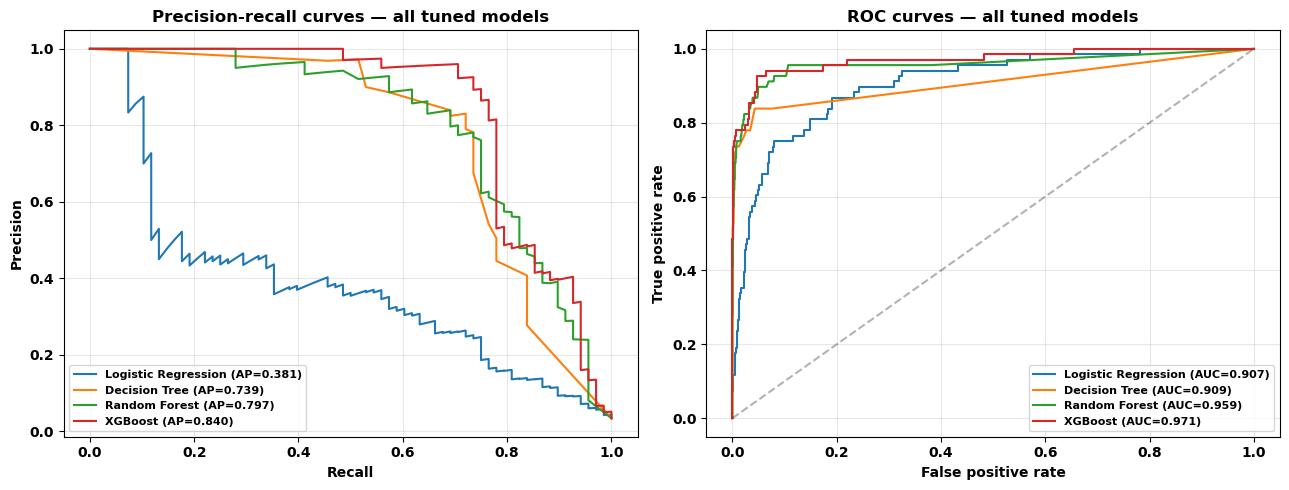

In [108]:
# Overlaid PR curves — all tuned models on the same axes for fair comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
for (name, (y_p, y_s)), color in zip(all_scores.items(), colors):
    ap = average_precision_score(y_test, y_s)
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_s)
    axes[0].plot(rec_c, prec_c, label=f"{name} (AP={ap:.3f})", color=color)
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-recall curves — all tuned models")
axes[0].legend(fontsize=8)

for (name, (y_p, y_s)), color in zip(all_scores.items(), colors):
    auc = roc_auc_score(y_test, y_s)
    fpr_c, tpr_c, _ = roc_curve(y_test, y_s)
    axes[1].plot(fpr_c, tpr_c, label=f"{name} (AUC={auc:.3f})", color=color)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curves — all tuned models")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

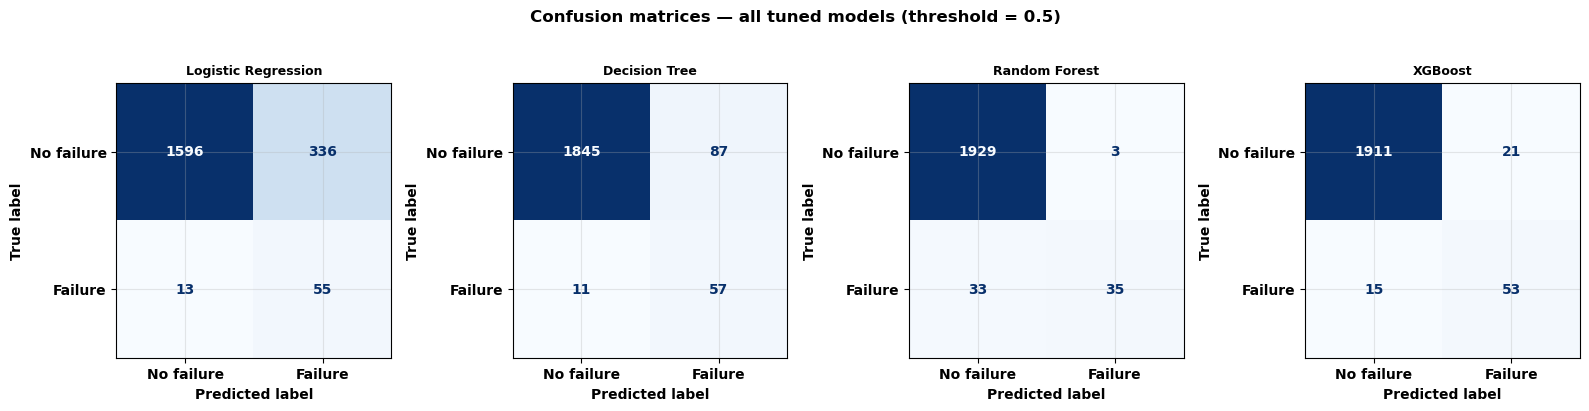

In [109]:
# Confusion matrices — all tuned models side by side
n = len(all_scores)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]
for ax, (name, (y_p, y_s)) in zip(axes, all_scores.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_p, ax=ax,
        display_labels=["No failure", "Failure"], cmap="Blues", colorbar=False,
    )
    ax.set_title(f"{name}", fontsize=9)
plt.suptitle("Confusion matrices — all tuned models (threshold = 0.5)", y=1.02)
plt.tight_layout()
plt.show()

=== Selected model: XGBoost ===

              precision    recall  f1-score   support

  No failure      0.992     0.989     0.991      1932
     Failure      0.716     0.779     0.746        68

    accuracy                          0.982      2000
   macro avg      0.854     0.884     0.869      2000
weighted avg      0.983     0.982     0.982      2000

    PR-AUC: 0.8401
   ROC-AUC: 0.9705
 precision: 0.7162
    recall: 0.7794
        f1: 0.7465
  macro_f1: 0.8686


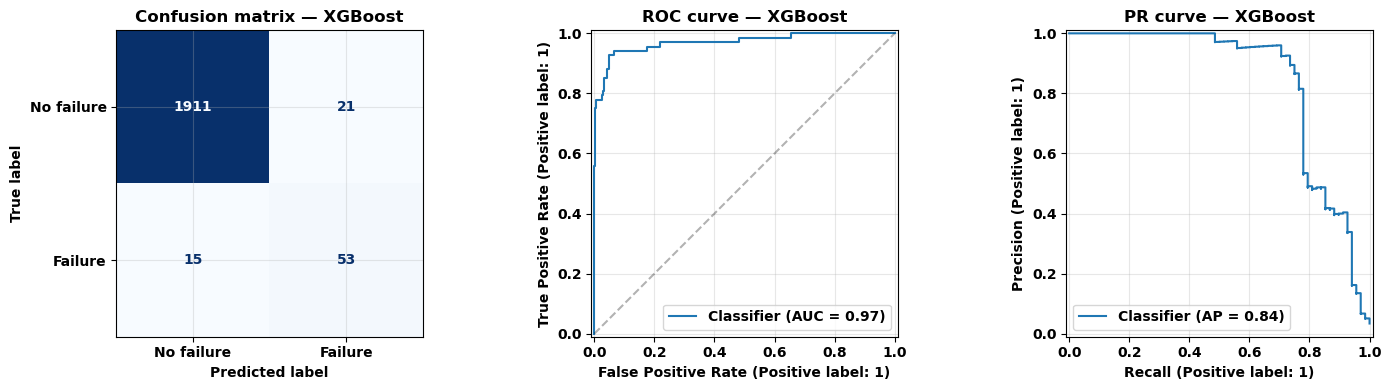

In [110]:
# Detailed evaluation of the selected best model
print(f"=== Selected model: {best_name} ===")
print()
print(classification_report(y_test, y_pred,
      target_names=["No failure", "Failure"], digits=3))

test_metrics = {
    "model":     best_name,
    "PR-AUC":    average_precision_score(y_test, y_score),
    "ROC-AUC":   roc_auc_score(y_test, y_score),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall":    recall_score(y_test, y_pred),
    "f1":        f1_score(y_test, y_pred, zero_division=0),
    "macro_f1":  f1_score(y_test, y_pred, average="macro"),
}
for k, v in test_metrics.items():
    if k != "model":
        print(f"{k:>10s}: {v:.4f}")

# Confusion matrix + curves for selected model
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0],
    display_labels=["No failure", "Failure"], cmap="Blues", colorbar=False,
)
axes[0].set_title(f"Confusion matrix — {best_name}")
RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title(f"ROC curve — {best_name}")
PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=axes[2])
axes[2].set_title(f"PR curve — {best_name}")
plt.tight_layout()
plt.show()


### 15.1 Decision threshold analysis        

Predictive maintenance has asymmetric error costs: a missed failure typically costs more than a false alarm     
The default 0.5 threshold is rarely optimal under heavy imbalance       

Reference thresholds:
 threshold  precision  recall    f1    f2
       0.2      0.509   0.794 0.621 0.714
       0.4      0.662   0.779 0.716 0.753
       0.5      0.716   0.779 0.746 0.766
       0.6      0.746   0.779 0.763 0.773
       0.8      0.815   0.779 0.797 0.786

Recommended operating threshold: 0.80
  At this threshold: precision = 0.815, recall = 0.779, F1 = 0.797, F2 = 0.786


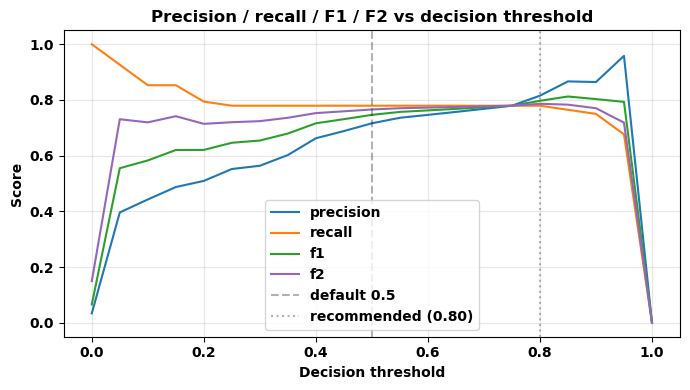

In [111]:
thresholds = np.round(np.linspace(0, 1, 21), 2)
rows = []
for thr in thresholds:
    yp = (y_score >= thr).astype(int)
    rows.append({
        "threshold": float(thr),
        "precision": precision_score(y_test, yp, zero_division=0),
        "recall":    recall_score(y_test, yp),
        "f1":        f1_score(y_test, yp, zero_division=0),
        "f2":        fbeta_score(y_test, yp, beta=2, pos_label=1, zero_division=0),
    })
thr_df = pd.DataFrame(rows)

ref = thr_df[thr_df["threshold"].isin([0.2, 0.4, 0.5, 0.6, 0.8])]
print("Reference thresholds:")
print(ref.round(3).to_string(index=False))

# Recommended operating point: threshold that maximises F2 on the failure class
best_thr_row = thr_df.loc[thr_df["f2"].idxmax()]
print(f"\nRecommended operating threshold: {best_thr_row['threshold']:.2f}")
print(f"  At this threshold: precision = {best_thr_row['precision']:.3f}, "
      f"recall = {best_thr_row['recall']:.3f}, "
      f"F1 = {best_thr_row['f1']:.3f}, F2 = {best_thr_row['f2']:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
for col, color in [("precision", "tab:blue"), ("recall", "tab:orange"),
                   ("f1", "tab:green"), ("f2", "tab:purple")]:
    ax.plot(thr_df["threshold"], thr_df[col], label=col, color=color)
ax.axvline(0.5, color="k", linestyle="--", alpha=0.3, label="default 0.5")
ax.axvline(best_thr_row["threshold"], color="tab:purple", linestyle=":", alpha=0.6,
           label=f"recommended ({best_thr_row['threshold']:.2f})")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / recall / F1 / F2 vs decision threshold")
ax.legend()
plt.tight_layout()
plt.show()

## 16. Interpretability — permutation importance and SHAP       

                feature  importance    std
            Torque [Nm]      0.6021 0.0140
    Air temperature [K]      0.4959 0.0540
 Rotational speed [rpm]      0.3994 0.0179
        Tool wear [min]      0.3407 0.0342
Process temperature [K]      0.2406 0.0247
                   Type      0.0280 0.0148


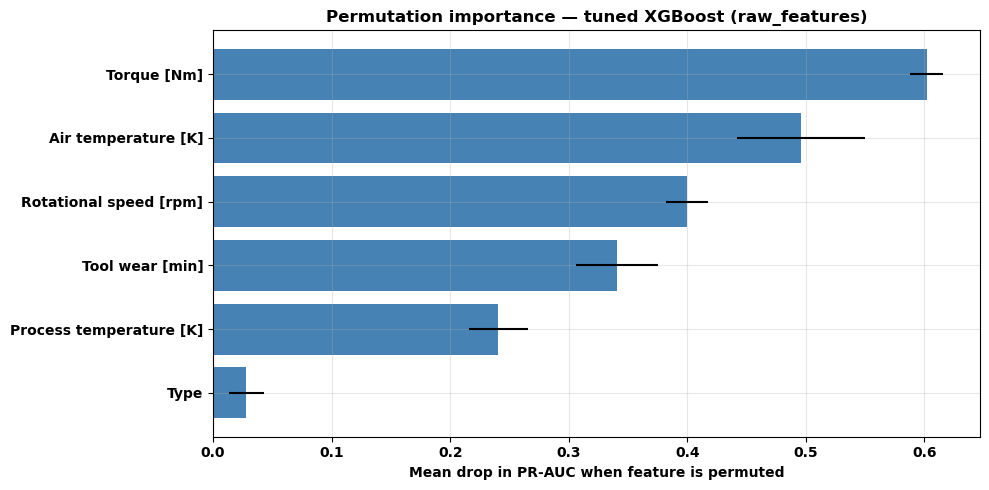

In [112]:
# Permutation importance on test set, scored by PR-AUC
perm = permutation_importance(
    best_pipe, Xte_raw, y_test, n_repeats=10,
    scoring="average_precision", random_state=RANDOM_STATE, n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":    Xte_raw.columns,
    "importance": perm.importances_mean,
    "std":        perm.importances_std,
}).sort_values("importance", ascending=False).reset_index(drop=True)
print(imp_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1],
        xerr=imp_df["std"][::-1], color="steelblue")
ax.set_xlabel("Mean drop in PR-AUC when feature is permuted")
ax.set_title(f"Permutation importance — tuned {best_name} (raw_features)")
plt.tight_layout()
plt.show()

                feature  mean_abs_shap
            Torque [Nm]         2.4835
        Tool wear [min]         2.0395
 Rotational speed [rpm]         1.5109
    Air temperature [K]         1.0078
Process temperature [K]         0.4354
                 Type_L         0.1484
                 Type_M         0.0585


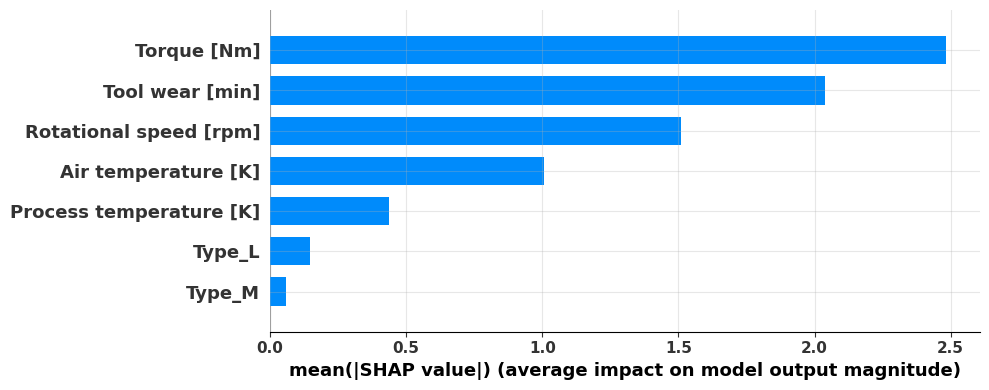

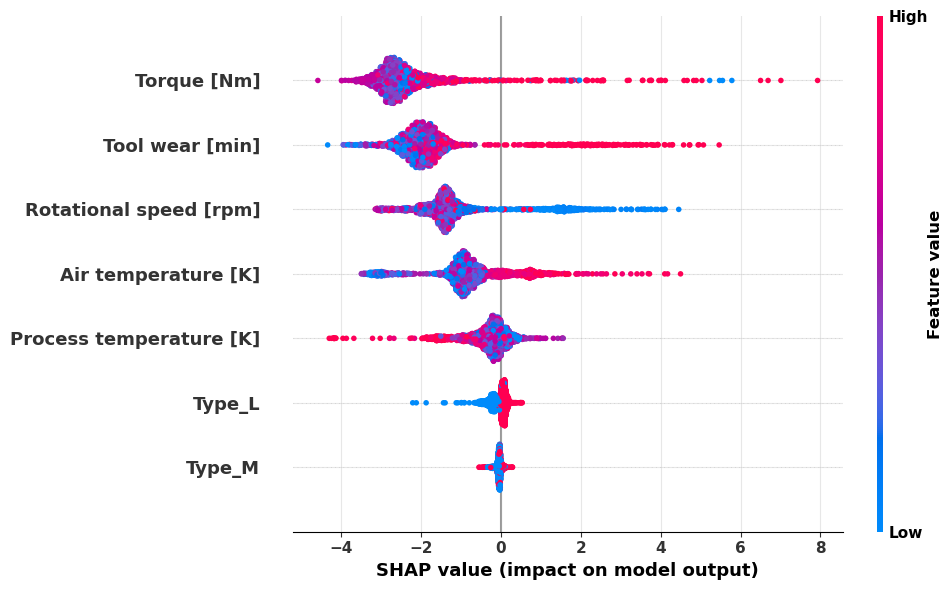

In [113]:
# SHAP for the final tree-based model
fitted_pre = best_pipe.named_steps["pre"]
fitted_clf = best_pipe.named_steps["clf"]
X_test_t   = fitted_pre.transform(Xte_raw)
feat_names_raw = fitted_pre.get_feature_names_out()

# Strip the ColumnTransformer "num__"/"cat__" prefixes for display
feat_names = [n.replace("num__", "").replace("cat__", "") for n in feat_names_raw]

explainer  = shap.TreeExplainer(fitted_clf)
shap_values = explainer.shap_values(X_test_t)

# Normalise SHAP output to the positive-class array
if isinstance(shap_values, list):
    sv_pos = shap_values[1]
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    sv_pos = shap_values[..., 1]
else:
    sv_pos = shap_values

# Mean |SHAP| table - saved for the joint synthesis sections below
mean_abs = np.abs(sv_pos).mean(axis=0)
shap_df = pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs})
shap_df = shap_df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
print(shap_df.round(4).to_string(index=False))

# Bar summary (mean |SHAP|)
plt.figure()
shap.summary_plot(sv_pos, X_test_t, feature_names=feat_names,
                  plot_type="bar", show=False)
plt.gcf().set_size_inches(10, 4)
plt.tight_layout()
plt.show()

# Beeswarm summary (signed SHAP per row)
plt.figure()
shap.summary_plot(sv_pos, X_test_t, feature_names=feat_names, show=False)
plt.gcf().set_size_inches(10, 6)
plt.tight_layout()
plt.show()

## 17. Synthetic-rule sensitivity audit     

- raw: six base sensor variables        
- engineered: raw + the three raw-product features used by Patel and Shanbhag       
- rule_audit: raw + three threshold-distance features derived directly from Matzka      

All four models are included so the effect of rule-encoding features can be assessed across the full model spectrum     

In [114]:
# The audit uses all four model families so the effect of rule-encoding
def evaluate_rule_audit(features, label):
    pre = make_preprocessor(features)
    Xtr = X_train_full[features]
    audit_models = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000, class_weight="balanced", C=1.0, random_state=RANDOM_STATE,
        ),
        "Decision Tree": DecisionTreeClassifier(
            class_weight="balanced", random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
        ),
        "XGBoost": XGBClassifier(
            scale_pos_weight=spw, eval_metric="logloss",
            n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1,
        ),
    }
    rows = []
    for name, clf in audit_models.items():
        pipe = Pipeline([("pre", pre), ("clf", clf)])
        sc = cross_validate(pipe, Xtr, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
        rows.append({
            "Feature set": label, "Model": name,
            "PR-AUC":  sc["test_pr_auc"].mean(),
            "ROC-AUC": sc["test_roc_auc"].mean(),
            "Recall":  sc["test_recall"].mean(),
            "F1 (pos)": sc["test_f1_pos"].mean(),
        })
    return pd.DataFrame(rows)


audit_all = []
for feats, lbl in [
    (raw_features,        "raw"),
    (engineered_features, "engineered"),
    (rule_audit_features, "rule_audit"),
]:
    print(f"--- {lbl} ({len(feats)} features) ---")
    res = evaluate_rule_audit(feats, lbl)
    print(res.round(3).to_string(index=False))
    audit_all.append(res)

audit_df = pd.concat(audit_all, ignore_index=True)

--- raw (6 features) ---
Feature set               Model  PR-AUC  ROC-AUC  Recall  F1 (pos)
        raw Logistic Regression   0.441    0.897   0.804     0.235
        raw       Decision Tree   0.407    0.778   0.565     0.618
        raw       Random Forest   0.758    0.970   0.421     0.575
        raw             XGBoost   0.784    0.972   0.727     0.731
--- engineered (9 features) ---
Feature set               Model  PR-AUC  ROC-AUC  Recall  F1 (pos)
 engineered Logistic Regression   0.472    0.928   0.838     0.285
 engineered       Decision Tree   0.515    0.837   0.683     0.708
 engineered       Random Forest   0.875    0.972   0.716     0.818
 engineered             XGBoost   0.859    0.976   0.812     0.819
--- rule_audit (9 features) ---
Feature set               Model  PR-AUC  ROC-AUC  Recall  F1 (pos)
 rule_audit Logistic Regression   0.854    0.958   0.841     0.627
 rule_audit       Decision Tree   0.720    0.916   0.838     0.844
 rule_audit       Random Forest   0.898 

PR-AUC by model x feature set:
Feature set            raw  engineered  rule_audit
Model                                             
Logistic Regression  0.441       0.472       0.854
Decision Tree        0.407       0.515       0.720
Random Forest        0.758       0.875       0.898
XGBoost              0.784       0.859       0.890


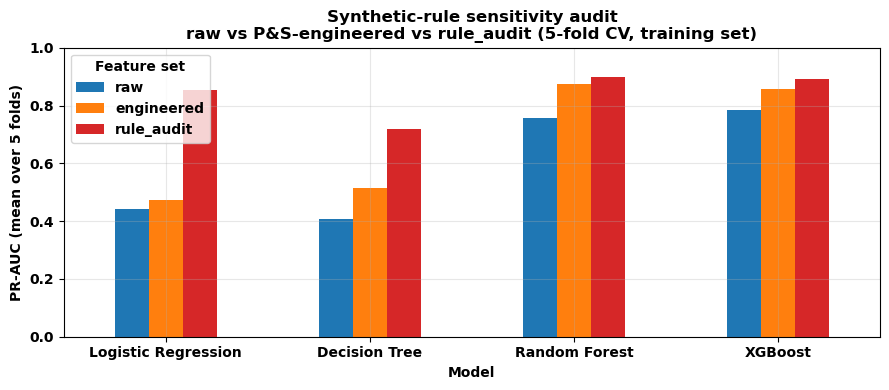

In [115]:
# Visualise the audit: PR-AUC by model x feature set (three-way comparison)
MODEL_ORDER = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]

pivot_pr = (audit_df.pivot(index="Model", columns="Feature set", values="PR-AUC")
            .reindex(index=MODEL_ORDER, columns=["raw", "engineered", "rule_audit"]))
print("PR-AUC by model x feature set:")
print(pivot_pr.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
pivot_pr.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e", "#d62728"])
ax.set_title(
    "Synthetic-rule sensitivity audit\n"
    "raw vs P&S-engineered vs rule_audit (5-fold CV, training set)"
)
ax.set_ylabel("PR-AUC (mean over 5 folds)")
ax.set_ylim(0, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Feature set")
plt.tight_layout()
plt.show()

## 18. Failure subtype diagnostic       

The subtype columns are NOT model inputs        
They are used here, after prediction, to characterise *which kinds of failures* the model catches       
Recall is reported alongside support counts so low-support subtypes are not over-interpreted        

In [116]:
sub_test = df.loc[X_test_full.index, SUBTYPE_COLS]
fail_mask_test = (y_test == 1)

rows = []
for sub in SUBTYPE_COLS:
    mask = (fail_mask_test) & (sub_test[sub] == 1)
    n = int(mask.sum())
    if n > 0:
        rec = float((y_pred[mask.values] == 1).mean())
        # Bootstrap CI for recall
        rng = np.random.default_rng(RANDOM_STATE)
        boot = []
        idx_arr = np.where(mask.values)[0]
        for _ in range(1000):
            sample = rng.choice(idx_arr, size=len(idx_arr), replace=True)
            boot.append((y_pred[sample] == 1).mean())
        ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    else:
        rec = float("nan"); ci_lo = ci_hi = float("nan")
    rows.append({
        "Subtype": sub, "n in test": n, "Recall": rec,
        "CI_2.5%": ci_lo, "CI_97.5%": ci_hi,
    })
subtype_df = pd.DataFrame(rows)
print("Recall by failure subtype (test set, with bootstrap 95% CI):")
print(subtype_df.round(3).to_string(index=False))

# Edge cases
no_sub = int((fail_mask_test & (sub_test.sum(axis=1) == 0)).sum())
sub_no_fail = int(((y_test == 0) & (sub_test.sum(axis=1) > 0)).sum())
print(f"\nTest failures with NO subtype flag set: {no_sub}")
print(f"Test rows with subtype flag set but Machine failure = 0: {sub_no_fail}")

Recall by failure subtype (test set, with bootstrap 95% CI):
Subtype  n in test  Recall  CI_2.5%  CI_97.5%
    TWF         10   0.100    0.000       0.3
    HDF         29   0.897    0.793       1.0
    PWF         13   0.923    0.769       1.0
    OSF         16   1.000    1.000       1.0
    RNF          0     NaN      NaN       NaN

Test failures with NO subtype flag set: 2
Test rows with subtype flag set but Machine failure = 0: 4


## 19. AI4I-PMDI-inspired robustness test       

1. Random missingness at 5%, 10%, 20% applied to numeric features and handled by the pipeline's median imputer      
2. Gaussian noise added to numeric features, scaled by each feature's standard deviation        

This is a *sensitivity analysis*, not a real industrial validation      

In [117]:
rng = np.random.default_rng(RANDOM_STATE)
numeric_raw = [c for c in raw_features if c != "Type"]

def add_missingness(X, frac):
    Xm = X.copy()
    for col in numeric_raw:
        mask = rng.random(len(Xm)) < frac
        Xm.loc[mask, col] = np.nan
    return Xm

def add_noise(X, sigma_frac):
    Xn = X.copy()
    for col in numeric_raw:
        s = X[col].std()
        Xn[col] = Xn[col] + rng.normal(0, sigma_frac * s, size=len(Xn))
    return Xn

robustness_rows = []

# Baseline (clean test set)
y_p = best_pipe.predict(Xte_raw)
y_s = best_pipe.predict_proba(Xte_raw)[:, 1]
robustness_rows.append({
    "Perturbation": "none", "level": 0.0,
    "PR-AUC": average_precision_score(y_test, y_s),
    "Recall": recall_score(y_test, y_p),
    "Precision": precision_score(y_test, y_p, zero_division=0),
})

for frac in [0.05, 0.10, 0.20]:
    Xm = add_missingness(Xte_raw, frac)
    y_p = best_pipe.predict(Xm)
    y_s = best_pipe.predict_proba(Xm)[:, 1]
    robustness_rows.append({
        "Perturbation": "missingness", "level": frac,
        "PR-AUC": average_precision_score(y_test, y_s),
        "Recall": recall_score(y_test, y_p),
        "Precision": precision_score(y_test, y_p, zero_division=0),
    })

for sigma in [0.05, 0.10, 0.20]:
    Xn = add_noise(Xte_raw, sigma)
    y_p = best_pipe.predict(Xn)
    y_s = best_pipe.predict_proba(Xn)[:, 1]
    robustness_rows.append({
        "Perturbation": "gaussian_noise", "level": sigma,
        "PR-AUC": average_precision_score(y_test, y_s),
        "Recall": recall_score(y_test, y_p),
        "Precision": precision_score(y_test, y_p, zero_division=0),
    })

robustness_df = pd.DataFrame(robustness_rows)
print(robustness_df.round(4).to_string(index=False))

  Perturbation  level  PR-AUC  Recall  Precision
          none   0.00  0.8401  0.7794     0.7162
   missingness   0.05  0.7566  0.7647     0.7123
   missingness   0.10  0.7115  0.6912     0.6714
   missingness   0.20  0.4926  0.4853     0.5500
gaussian_noise   0.05  0.8314  0.7794     0.6883
gaussian_noise   0.10  0.6703  0.7206     0.5833
gaussian_noise   0.20  0.5384  0.6176     0.4330


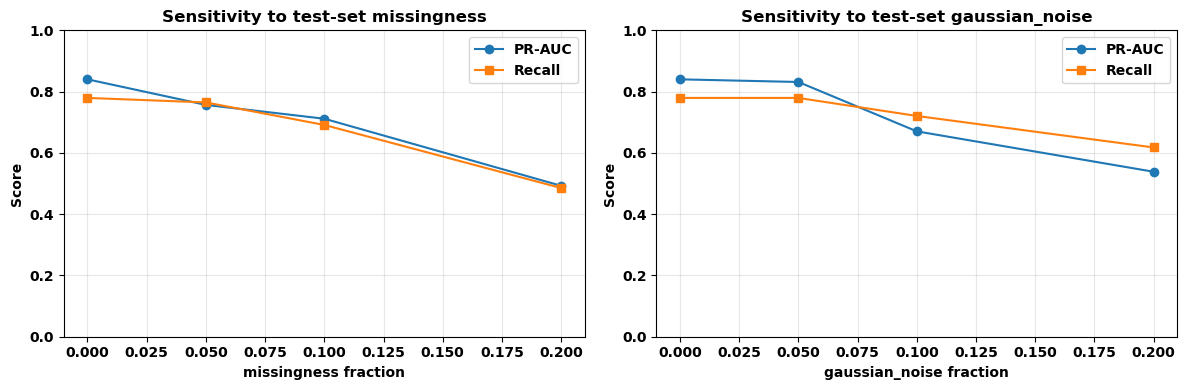

In [118]:
# Robustness chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, kind in zip(axes, ["missingness", "gaussian_noise"]):
    sub = robustness_df[robustness_df["Perturbation"] == kind]
    base = robustness_df.iloc[0]  # the 'none' row
    levels = [0.0] + sub["level"].tolist()
    pr   = [base["PR-AUC"]] + sub["PR-AUC"].tolist()
    rec  = [base["Recall"]] + sub["Recall"].tolist()
    ax.plot(levels, pr, "o-", label="PR-AUC", color="tab:blue")
    ax.plot(levels, rec, "s-", label="Recall", color="tab:orange")
    ax.set_xlabel(f"{kind} fraction")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)
    ax.set_title(f"Sensitivity to test-set {kind}")
    ax.legend()
plt.tight_layout()
plt.show()

## Part III — Joint synthesis       

## 20. Predictive performance under class imbalance     

In [119]:
# numbers were computed in Sections 12–15
# This cell summarises them
print(f"selected model: {best_name} on raw_features:")
print(f"  Test PR-AUC : {test_metrics['PR-AUC']:.4f}")
print(f"  Test ROC-AUC: {test_metrics['ROC-AUC']:.4f}")
print(f"  Test recall : {test_metrics['recall']:.4f}")
print(f"  Test precision: {test_metrics['precision']:.4f}")
print(f"  Test F1     : {test_metrics['f1']:.4f}")
print()
print("Imbalance-strategy comparison (from Section 13):")
print(imb_results.round(3).to_string(index=False))

selected model: XGBoost on raw_features:
  Test PR-AUC : 0.8401
  Test ROC-AUC: 0.9705
  Test recall : 0.7794
  Test precision: 0.7162
  Test F1     : 0.7465

Imbalance-strategy comparison (from Section 13):
              Model                        Strategy  PR-AUC  Macro F1  Recall  Precision
Logistic Regression class_weight / scale_pos_weight   0.441     0.567   0.804      0.137
      Decision Tree class_weight / scale_pos_weight   0.534     0.706   0.864      0.305
      Random Forest class_weight / scale_pos_weight   0.758     0.782   0.421      0.916
            XGBoost class_weight / scale_pos_weight   0.735     0.819   0.775      0.564
Logistic Regression               RandomOverSampler   0.443     0.566   0.801      0.137
      Decision Tree               RandomOverSampler   0.469     0.705   0.856      0.304
      Random Forest               RandomOverSampler   0.751     0.830   0.572      0.814
            XGBoost               RandomOverSampler   0.750     0.742   0.845   

## 21. Influential variables        

In [120]:
# Build a side-by-side comparison of EDA effect sizes (Robin, Section 5) vs model importances (Mazen, Section 16).
def normalise_name(s):
    return (s.replace("[K]", "").replace("[W]", "").replace("[Nm]", "")
             .replace("[rpm]", "").replace("[min]", "").replace("[Nm*min]", "")
             .replace("num__", "").replace("cat__", "").strip())

# eff_df from Section 5 (Robin EDA), imp_df from Section 16 (Mazen perm importance), shap_df from Section 16 (Mazen SHAP)
eda = eff_df.copy()
d_col = [c for c in eda.columns if "Cohen" in c][0]
eda["abs_d"] = eda[d_col].abs()
eda["key"] = eda["variable"].map(normalise_name)
eda_rank = eda.sort_values("abs_d", ascending=False)[["key", "abs_d"]]
eda_rank["rank_eda"] = range(1, len(eda_rank) + 1)

perm = imp_df.copy()
perm["key"] = perm["feature"].map(normalise_name)
perm_rank = perm.sort_values("importance", ascending=False)[["key", "importance"]]
perm_rank["rank_model"] = range(1, len(perm_rank) + 1)

shap = shap_df.copy()
shap["key"] = shap["feature"].map(normalise_name)
shap = (shap.groupby("key", as_index=False)["mean_abs_shap"].sum()
            .sort_values("mean_abs_shap", ascending=False))
shap["rank_shap"] = range(1, len(shap) + 1)

agree = (eda_rank.merge(perm_rank, on="key", how="outer")
                  .merge(shap[["key", "rank_shap", "mean_abs_shap"]], on="key", how="outer"))
print("EDA vs model interpretation — variable rankings:")
print(agree.sort_values("rank_eda").round(3).to_string(index=False))

EDA vs model interpretation — variable rankings:
                key  abs_d  rank_eda  importance  rank_model  rank_shap  mean_abs_shap
             Torque  1.077       1.0       0.602         1.0        1.0          2.484
          Tool wear  0.586       2.0       0.341         4.0        2.0          2.040
    Air temperature  0.458       3.0       0.496         2.0        4.0          1.008
   Rotational speed  0.244       4.0       0.399         3.0        3.0          1.511
Process temperature  0.199       5.0       0.241         5.0        5.0          0.435
               Type    NaN       NaN       0.028         6.0        NaN            NaN
             Type_L    NaN       NaN         NaN         NaN        6.0          0.148
             Type_M    NaN       NaN         NaN         NaN        7.0          0.059


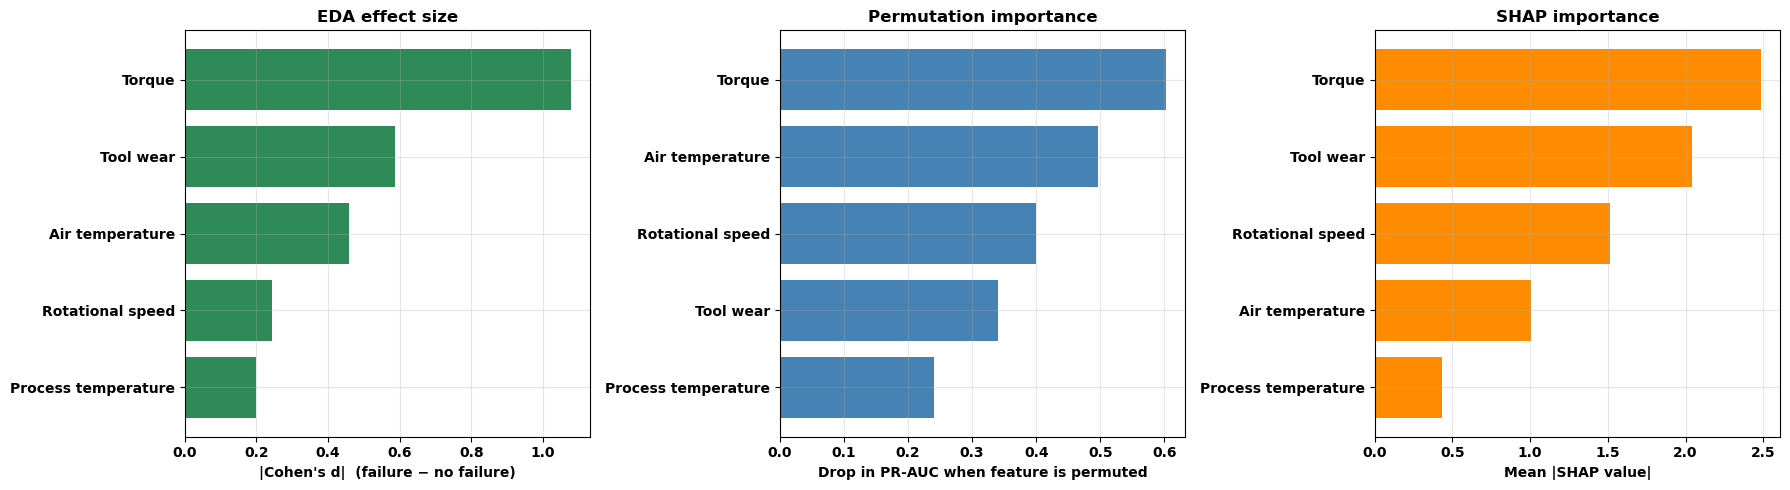

In [121]:
# Three-panel chart: EDA effect size, permutation importance, SHAP
top = (agree.dropna(subset=["abs_d", "importance", "mean_abs_shap"])
             .sort_values("abs_d", ascending=False)
             .head(8))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# EDA effect size (sorted by Cohen's d)
s1 = top.sort_values("abs_d", ascending=True)
axes[0].barh(s1["key"], s1["abs_d"], color="seagreen")
axes[0].set_xlabel("|Cohen's d|  (failure − no failure)")
axes[0].set_title("EDA effect size")

# Permutation importance (sorted by permutation importance)
s2 = top.sort_values("importance", ascending=True)
axes[1].barh(s2["key"], s2["importance"], color="steelblue")
axes[1].set_xlabel("Drop in PR-AUC when feature is permuted")
axes[1].set_title("Permutation importance")

# SHAP mean |value| (sorted by SHAP)
s3 = top.sort_values("mean_abs_shap", ascending=True)
axes[2].barh(s3["key"], s3["mean_abs_shap"], color="darkorange")
axes[2].set_xlabel("Mean |SHAP value|")
axes[2].set_title("SHAP importance")

plt.tight_layout()
plt.show()

## 22. Synthetic-rule sensitivity, subtype recall, robustness       

In [122]:
# All numbers computed in Sections 17–19. Summary here
print("Synthetic-rule sensitivity audit (Section 17):")
print(pivot_pr.round(3))
print()
print("Subtype recall (Section 18):")
print(subtype_df.round(3).to_string(index=False))
print()
print("Robustness analysis (Section 19):")
print(robustness_df.round(4).to_string(index=False))

Synthetic-rule sensitivity audit (Section 17):
Feature set            raw  engineered  rule_audit
Model                                             
Logistic Regression  0.441       0.472       0.854
Decision Tree        0.407       0.515       0.720
Random Forest        0.758       0.875       0.898
XGBoost              0.784       0.859       0.890

Subtype recall (Section 18):
Subtype  n in test  Recall  CI_2.5%  CI_97.5%
    TWF         10   0.100    0.000       0.3
    HDF         29   0.897    0.793       1.0
    PWF         13   0.923    0.769       1.0
    OSF         16   1.000    1.000       1.0
    RNF          0     NaN      NaN       NaN

Robustness analysis (Section 19):
  Perturbation  level  PR-AUC  Recall  Precision
          none   0.00  0.8401  0.7794     0.7162
   missingness   0.05  0.7566  0.7647     0.7123
   missingness   0.10  0.7115  0.6912     0.6714
   missingness   0.20  0.4926  0.4853     0.5500
gaussian_noise   0.05  0.8314  0.7794     0.6883
gaussian_noi